# One-shot Pseudo-Labeling 

Goal: Generate **HIGH-QUALITY** pseudo-labels for ensemble training


- Load `models/roberta-dapt-dynamic/` (best balanced model)
- Load unlabeled chunks from DuckDB, exclude labeled data
- Batch inference, store probabilities, entropy
- **STRICT Filters**: confidence ≥ **0.92**, entropy < **0.3**, word count 50–200
- Cap ≤ **1,500** per class (9,000 total → **2:1 pseudo:real ratio**)


Outputs:
- data/pseudo_labeled_chunks.csv
- results/pseudo_labeling_stats.json
- results/pseudo_label_quality.png


In [1]:
import os
import json
import numpy as np
import pandas as pd
import torch
import duckdb
import warnings
from tqdm.auto import tqdm
from scipy.stats import entropy
from transformers import RobertaTokenizer, RobertaForSequenceClassification
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

warnings.filterwarnings('ignore')

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print("✅ Libraries loaded")
print(f"Device: {device}")


✅ Libraries loaded
Device: cuda


## 1) Load model and label encoder


In [2]:
print("Loading dynamic model (best balanced performance)...")
tokenizer = RobertaTokenizer.from_pretrained('models/roberta-dapt-dynamic')
model = RobertaForSequenceClassification.from_pretrained('models/roberta-dapt-dynamic')
model = model.to(device)
model.eval()

with open('data/roberta_label_encoder.pkl', 'rb') as f:
    label_encoder = pickle.load(f)
labels = list(label_encoder.classes_)
num_labels = len(labels)
print("✅ Model and label encoder loaded")


Loading dynamic model (best balanced performance)...
✅ Model and label encoder loaded


## 2) Load unlabeled chunks from DuckDB, exclude labeled ones


In [3]:
# ✅ CRITICAL: Load from Phase 1 output (has original DuckDB chunk_ids)\nprint("Loading labeled chunk_ids from data/augmented_training_data.csv ...")
labeled = pd.read_csv('data/augmented_training_data.csv')
labeled_ids = set(labeled['chunk_id'].values)
print(f"✅ Labeled IDs: {len(labeled_ids):,}")

print("Connecting to DuckDB...")
conn = duckdb.connect('debates_brexit_chunked.duckdb', read_only=True)
query = """
SELECT 
  chunk_id,
  chunk_text,
  LENGTH(chunk_text) - LENGTH(REPLACE(chunk_text, ' ', '')) + 1 AS word_count
FROM chunks
WHERE chunk_text IS NOT NULL
"""
all_chunks = conn.execute(query).df()
conn.close()
print(f"✅ Loaded {len(all_chunks):,} total chunks from DuckDB")

unlabeled = all_chunks[~all_chunks['chunk_id'].isin(labeled_ids)].copy()
print(f"✅ Filtered to {len(unlabeled):,} unlabeled chunks")

# Length filter as per plan
unlabeled = unlabeled[(unlabeled['word_count'] >= 50) & (unlabeled['word_count'] <= 200)].copy()
print(f"✅ After length filter (50–200): {len(unlabeled):,}")


✅ Labeled IDs: 5,637
Connecting to DuckDB...
✅ Loaded 62,847 total chunks from DuckDB
✅ Filtered to 60,501 unlabeled chunks
✅ After length filter (50–200): 49,115


## 3) Batch prediction with probabilities and entropy


In [4]:
def predict_batch(texts, batch_size=64):
    all_probs, all_preds, all_entropy = [], [], []
    with torch.no_grad():
        for i in tqdm(range(0, len(texts), batch_size), desc='Predicting'):
            batch = texts[i:i+batch_size]
            inputs = tokenizer(batch, truncation=True, max_length=384, padding=True, return_tensors='pt')
            inputs = {k: v.to(device) for k, v in inputs.items()}
            outputs = model(**inputs)
            logits = outputs.logits
            probs = torch.softmax(logits, dim=-1).cpu().numpy()
            preds = probs.argmax(axis=-1)
            ent = entropy(probs, axis=-1)
            all_probs.extend(probs)
            all_preds.extend(preds)
            all_entropy.extend(ent)
    return np.array(all_probs), np.array(all_preds), np.array(all_entropy)

print("Running inference...")
probs, preds, ent = predict_batch(unlabeled['chunk_text'].tolist(), batch_size=64)
max_conf = probs.max(axis=-1)

unlabeled['predicted_label_id'] = preds
unlabeled['predicted_label'] = label_encoder.inverse_transform(preds)
unlabeled['confidence'] = max_conf
unlabeled['entropy'] = ent
print("✅ Inference complete")


Running inference...


Predicting:   0%|          | 0/768 [00:00<?, ?it/s]

✅ Inference complete


## 4) Apply filters and cap per class


In [7]:
print("Applying STRICT filters: confidence ≥ 0.92 and entropy < 0.3 ...")
print("(Stricter thresholds for ensemble training - prioritize quality over quantity)")
filtered = unlabeled[(unlabeled['confidence'] >= 0.92) & (unlabeled['entropy'] < 0.3)].copy()
print(f"After filters: {len(filtered):,}")

print("\nPer-class distribution before capping:")
print(filtered['predicted_label'].value_counts().sort_index())

# BALANCED PSEUDO-LABELING with 1500 cap per class (9000 total)
# This gives us a healthy 2:1 pseudo:real ratio (9000:4606)
cap = 1500  # Balanced cap for ensemble training

capped_frames = []
for label in labels:
    subset = filtered[filtered['predicted_label'] == label]
    if len(subset) > cap:
        subset = subset.nlargest(cap, 'confidence')  # Take top 4,386 by confidence
    capped_frames.append(subset)

pseudo_df = pd.concat(capped_frames, ignore_index=True)
print("\nPer-class distribution after capping (≤1,500 per class):")
print(pseudo_df['predicted_label'].value_counts().sort_index())
print(f"\nTotal pseudo-labeled: {len(pseudo_df):,}")
print(f"Pseudo:Real ratio = {len(pseudo_df)}/4606 = {len(pseudo_df)/4606:.2f}:1")


Applying STRICT filters: confidence ≥ 0.92 and entropy < 0.3 ...
(Stricter thresholds for ensemble training - prioritize quality over quantity)
After filters: 33,607

Per-class distribution before capping:
predicted_label
Conflict         6609
Economic         9720
Human Impact     4622
Moral Value      4132
None             4816
Powerlessness    3708
Name: count, dtype: int64

Per-class distribution after capping (≤1,500 per class):
predicted_label
Conflict         1500
Economic         1500
Human Impact     1500
Moral Value      1500
None             1500
Powerlessness    1500
Name: count, dtype: int64

Total pseudo-labeled: 9,000
Pseudo:Real ratio = 9000/4606 = 1.95:1


## 5) Save outputs and quality plots


✅ Saved data/pseudo_labeled_chunks.csv
✅ Saved results/pseudo_labeling_stats.json
✅ Saved results/pseudo_label_quality.png


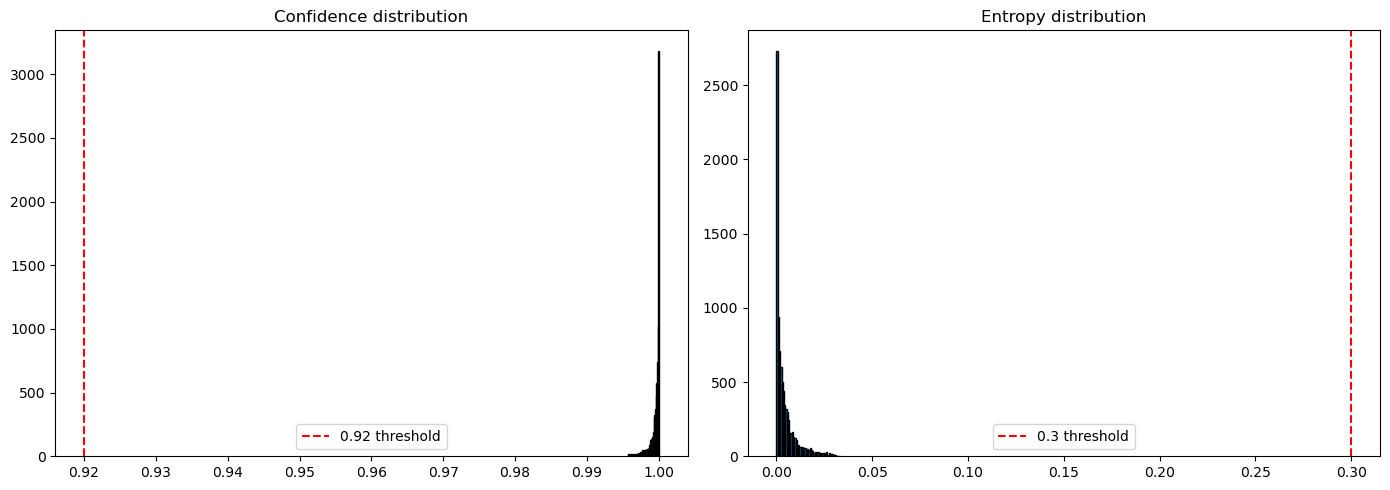

In [12]:
os.makedirs('data', exist_ok=True)
output = pseudo_df[['chunk_id', 'chunk_text', 'predicted_label', 'confidence', 'entropy']].copy()
output.rename(columns={'predicted_label': 'pseudo_label'}, inplace=True)
output.to_csv('data/pseudo_labeled_chunks.csv', index=False)
print("✅ Saved data/pseudo_labeled_chunks.csv")

# Stats
stats = {
    'total_pseudo_labeled': int(len(pseudo_df)),
    'per_class_counts': pseudo_df['predicted_label'].value_counts().to_dict(),
    'avg_confidence': float(pseudo_df['confidence'].mean()),
    'avg_entropy': float(pseudo_df['entropy'].mean()),
}
os.makedirs('results', exist_ok=True)
with open('results/pseudo_labeling_stats.json', 'w') as f:
    json.dump(stats, f, indent=2)
print("✅ Saved results/pseudo_labeling_stats.json")

# Plot confidence & entropy hist
fig, axes = plt.subplots(1, 2, figsize=(14,5))
axes[0].hist(pseudo_df['confidence'], bins=50, edgecolor='black')
axes[0].axvline(0.92, color='red', linestyle='--', label='0.92 threshold')
axes[0].set_title('Confidence distribution')
axes[0].legend()

axes[1].hist(pseudo_df['entropy'], bins=50, edgecolor='black')
axes[1].axvline(0.3, color='red', linestyle='--', label='0.3 threshold')
axes[1].set_title('Entropy distribution')
axes[1].legend()

plt.tight_layout()
plt.savefig('results/pseudo_label_quality.png', dpi=300, bbox_inches='tight')
print("✅ Saved results/pseudo_label_quality.png")
